# SNAFU \- Pre\-processing

In [1]:
#Importing libraries
import snafu
import pandas as pd
import numpy as np
import unidecode
from spellchecker import SpellChecker
import os
import nltk
import collections
import json
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr, shapiro
import plotly.graph_objects as go
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
from nltk.stem import WordNetLemmatizer
from collections import defaultdict
from tqdm import tqdm
from Levenshtein import distance as levenshtein_distance

In [2]:
# Reading the CSV file with 'latin1' encoding which is common for Italian datasets
df_1 = pd.read_csv("fluenze_pit.csv", encoding='latin1')

df_1 = df_1.rename(columns={"ï»¿id": "id"})

# Escludi ID 48
df_1 = df_1[df_1["id"] != 48].copy()

print("Unique IDs after excluding ID 48:", df_1["id"].nunique())

Unique IDs after excluding ID 48: 109


In [3]:
# Set environment variable to specify download directory for NLTK data
nltk_data_dir = os.path.expanduser('~/nltk_data')
os.makedirs(nltk_data_dir, exist_ok=True)

# Adding path to NLTK data if not already included
if nltk_data_dir not in nltk.data.path:
    nltk.data.path.append(nltk_data_dir)

# Download 'wordnet' into the specified directory
nltk.download('wordnet', download_dir=nltk_data_dir)

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

Download files

https://github\.com/commonsense/conceptnet5/wiki/Downloads <\- conceptnet assetions 5\.7\.0\.

In [4]:
# Create a lemmatizer (plural → singular)
lemmatizer = WordNetLemmatizer()

# ConceptNet file path
CONCEPTNET_FILE_PATH = "/datasets/datasets/conceptnet-assertions-5.7.0.csv"

# Categories (your listnum values) → Italian root word
target_categories = {
    "animals": "animale",
    "fruits": "frutta",
    "colors": "colore",
    "foods": "cibo",
    "vegetables": "verdura",
    "supermarket items": "supermercato",
    "tools": "attrezzo"
}

# Initialize result dictionary
allWords = {cat: set() for cat in target_categories}

# Relations to include
valid_relations = {"/r/IsA", "/r/InstanceOf", "/r/FormOf", "/r/Synonym", "/r/DefinedAs", "/r/PartOf"}

# Read ConceptNet in chunks (streaming mode)
chunk_size = 100000
reader = pd.read_csv(
    CONCEPTNET_FILE_PATH,
    sep='\t',
    header=None,
    usecols=[1, 2, 3],
    names=["rel", "start", "end"],
    chunksize=chunk_size
)

# Wrap the reader in tqdm for progress bar
print("Building category dictionary from ConceptNet...")
for chunk in tqdm(reader, desc="Processing ConceptNet"):
    # Filter relations and language
    chunk = chunk[
        (chunk["rel"].isin(valid_relations)) &
        (chunk["start"].str.startswith("/c/it/")) &
        (chunk["end"].str.startswith("/c/it/"))
    ]

    # Extract word (e.g., /c/it/mela → mela)
    chunk["start"] = chunk["start"].apply(lambda x: x.split("/")[3])
    chunk["end"] = chunk["end"].apply(lambda x: x.split("/")[3])
    chunk["rel"] = chunk["rel"].apply(lambda x: x.split("/")[2])

    # Fill dictionary
    for cat, root in target_categories.items():
        matches = chunk[
            chunk["start"].str.contains(root) | chunk["end"].str.contains(root)
        ]
        for _, row in matches.iterrows():
            allWords[cat].add(lemmatizer.lemmatize(row["start"]))
            allWords[cat].add(lemmatizer.lemmatize(row["end"]))

# Save the final dictionary
with open("allWords_it.json", "w", encoding="utf-8") as f:
    json.dump({k: sorted(list(v)) for k, v in allWords.items()}, f, ensure_ascii=False, indent=2)

Building category dictionary from ConceptNet...
Processing ConceptNet: 139it [02:13,  1.18it/s]/tmp/ipykernel_552/2927691789.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["start"] = chunk["start"].apply(lambda x: x.split("/")[3])
/tmp/ipykernel_552/2927691789.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk["end"] = chunk["end"].apply(lambda x: x.split("/")[3])
/tmp/ipykernel_552/2927691789.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [5]:
nltk.download('wordnet')

# Load ConceptNet-based dictionary
with open("allWords_it.json", encoding="utf-8") as f:
    allWords = json.load(f)
    allWords = {k: set(v) for k, v in allWords.items()}

# Categories to apply spellcheck to (rest only cleaned)
semantic_categories = set(allWords.keys())

# Spellcheckers
spell_it = SpellChecker(language="it")
spell_en = SpellChecker(language="en")

# Lemmatizer for singularization
lemmatizer = WordNetLemmatizer()

# Track not found terms
not_found = []

# Normalize and lemmatize input word
def preprocess(word):
    if pd.isnull(word):
        return ""
    word = str(word).lower()
    word = unidecode.unidecode(word)
    word = word.replace("-", "")
    word = lemmatizer.lemmatize(word)
    return word

#Levenshtein correction using semantic dictionary
def correct_with_levenshtein(word, category_words):
    best_match = word
    best_dist = 2  # max edit distance accepted
    for candidate in category_words:
        dist = levenshtein_distance(word, candidate)
        if dist < best_dist:
            best_match = candidate
            best_dist = dist
    return best_match

#Final cleaning pipeline
def clean_item(row):
    word = preprocess(row["item"])
    category = row["listnum"]

    if category not in semantic_categories:
        return word  # clean only

    # If already valid
    if word in allWords[category]:
        return word

    # TryLevenshtein
    corrected = correct_with_levenshtein(word, allWords[category])
    if corrected != word:
        return corrected

    # If no Levenshtein match, try spellchecker IT
    if word in spell_it:
        return word
    suggestion_it = spell_it.correction(word)
    if suggestion_it and suggestion_it in allWords[category]:
        return suggestion_it

    # Try EN
    if word in spell_en:
        return word
    suggestion_en = spell_en.correction(word)
    if suggestion_en and suggestion_en in allWords[category]:
        return suggestion_en

    # Log unknown words for manual review
    not_found.append((row["item"], word, category))
    return word

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
# Apply
df_1["item_cleaned"] = df_1.apply(clean_item, axis=1)

# Save cleaned CSV
df_1.to_csv("fluenze_pit_preprocessed.csv", index=False, encoding="utf-8")

# Count words not found by category
if not_found:
    counts = collections.Counter([cat for _, _, cat in not_found])
    print("Words not found for category:")
    for cat, count in counts.items():
        print(f" - {cat}: {count} words")

    # Save CSV only if there are entries
    pd.DataFrame(not_found, columns=["original", "processed", "listnum"]).drop_duplicates().to_csv(
        "not_found.csv", index=False, encoding="utf-8"
    )
    print(f"Saved file: not_found.csv ({len(not_found)} words)")
else:
    print("No words found. not_found.csv was not created.")


No words found. not_found.csv was not created.


In [7]:
df_cleaned = df_1.copy()

df_cleaned["item"] = df_cleaned["item_cleaned"]

df_cleaned.drop(columns=["item_cleaned"], inplace=True)

df_cleaned.to_csv("fluenze_pit_cleaned.csv", index=False, encoding="utf-8")

In [8]:
df_preprocessed = pd.read_csv('fluenze_pit_preprocessed.csv', encoding='utf-8')
df_preprocessed.rename(columns={'ï»¿id': 'id'}, inplace=True)
df_preprocessed.to_csv('fluenze_pit_preprocessed.csv', index=False, encoding='utf-8')

In [9]:
df_cleaned = pd.read_csv('fluenze_pit_cleaned.csv', encoding='utf-8')
df_cleaned.rename(columns={'ï»¿id': 'id'}, inplace=True)
df_cleaned.to_csv('fluenze_pit_cleaned.csv', index=False, encoding='utf-8')


# SNAFU \- Data proprieties

Download files

https://osf\.io/zg7sc/ <\- SUBTLEX\-IT for word\_freq

https://osf\.io/ctp5k/ <\- ItAoA for aoa

In [10]:
#Fit the aoa dataset with the column values ​​required by SNAFU
aoa_df = pd.read_excel("ItAoA.xlsx", sheet_name="Database")
aoa_snafu = aoa_df[["Ita_Word", "M_AoA"]].rename(columns={"Ita_Word": "word", "M_AoA": "val"})
aoa_snafu.to_csv("aoa-it_snafu.csv", index=False, encoding="utf-8-sig", sep=",", header=False)
aoa_snafu.head()

,word,val
0,abbaglio,9.36
1,abbandonato,6.68
2,abbondanza,6.96
3,abbracciare,2.84
4,abbraccio,4.20


In [11]:
#Fit the subtlex-it dataset with the column values ​​required by SNAFU
freq_df = pd.read_csv("subtlex-it.csv", encoding="latin1", sep=";")
freq_cleaned = freq_df[["wordform", "freq_count"]].rename(columns={"wordform": "word", "freq_count": "val"})
freq_cleaned = freq_cleaned.dropna(subset=["word", "val"])

#Remove all non-alphabetic characters
freq_cleaned = freq_cleaned[freq_cleaned["word"].str.isalpha()]
freq_cleaned.to_csv("subtlex-it_snafu.csv", index=False, encoding="utf-8-sig", sep=",", header=False)
freq_cleaned.head()

,word,val
3,non,2340479.0
4,che,2293840.0
5,è,2288908.0
6,di,2202526.0
9,un,1499479.0


## Colors

In [12]:
#File paths
input_data_path = "fluenze_pit_cleaned.csv"
scheme_path = "snafu_Italian_scheme_Colors_Pupillo.csv"
freq_path = "subtlex-it_snafu.csv"
aoa_path = "aoa-it_snafu.csv"
output_csv = "snafu_colors_properties_it.csv"
output_group_csv = "snafu_colors_group_means.csv"

df_cleaned = pd.read_csv("fluenze_pit_cleaned.csv", encoding="latin1", dtype={"id": str})
print(f"Total unique IDs in df_cleaned: {df_cleaned['id'].nunique()}")

#Create subject → group mapping
subject_group_df = df_cleaned[["id", "group"]].drop_duplicates()
print(f"ID→group mapping created for {len(subject_group_df)} ids")

#Load only colors category data with SNAFU
fluencydata = snafu.load_fluency_data(
    input_data_path,
    category="colors",
    removeNonAlphaChars=True,
    group=["MCI", "HC", "frailty"],
    hierarchical=True,
)

#Subject IDs processed by SNAFU (convert to str)
subject_ids = [str(sub) for sub in fluencydata.subs]
print(f"SNAFU has included {len(subject_ids)} ids")

#Comparison with original IDs
original_ids_colors = set(df_cleaned[df_cleaned["category"] == "colors"]["id"].unique())
processed_ids = set(subject_ids)
discarded_ids = original_ids_colors - processed_ids
print(f"SNAFU has discarded {len(discarded_ids)} ids: {sorted(discarded_ids)}")

#Metrics
cluster_switches = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static")
switch_rate = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static", switchrate=True)
cluster_size = snafu.clusterSize(fluencydata.labeledlists, scheme_path)
perseverations = snafu.perseverations(fluencydata.labeledlists)
intrusions = snafu.intrusions(fluencydata.labeledlists, scheme_path)

#In case of missing values ​​for AoA and frequency replace spaces with NaN when necessary
try:
    word_freq_result = snafu.wordFrequency(fluencydata.labeledlists, data=freq_path, missing=None)
    word_freq = word_freq_result[0] if isinstance(word_freq_result, tuple) else word_freq_result
except:
    word_freq = [np.nan] * len(subject_ids)

try:
    aoa_result = snafu.ageOfAcquisition(fluencydata.labeledlists, data=aoa_path, missing=None)
    aoa = aoa_result[0] if isinstance(aoa_result, tuple) else aoa_result
except:
    aoa = [np.nan] * len(subject_ids)


results = pd.DataFrame({
    "id": subject_ids,
    "cluster_switches": cluster_switches,
    "switch_rate": switch_rate,
    "cluster_size": cluster_size,
    "perseverations": perseverations,
    "intrusions": intrusions,
    "word_freq": word_freq,
    "aoa": aoa
})

#Merge group info using 'id'
results = results.merge(subject_group_df, on="id", how="left")

#Save full metrics CSV
results["id"] = results["id"].astype(int)
results = results.sort_values("id")

for col in results.select_dtypes(include=["float", "int"]).columns:
    results[col] = results[col].round(2)

results.to_csv(output_csv, index=False, encoding="latin1")

#Group-level means
group_means = results.groupby("group").mean(numeric_only=True).reset_index()
for col in group_means.select_dtypes(include=["float", "int"]).columns:
    group_means[col] = group_means[col].round(2)

group_means.to_csv(output_group_csv, index=False, encoding="latin1")

Total unique IDs in df_cleaned: 109
ID→group mapping created for 109 ids
SNAFU has included 109 ids
SNAFU has discarded 0 ids: []
/root/venv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/root/venv/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Animals

In [13]:
#File paths
input_data_path = "fluenze_pit_cleaned.csv"
scheme_path = "snafu_Italian_scheme_Animals_Costantini.csv"
freq_path = "subtlex-it_snafu.csv"
aoa_path = "aoa-it_snafu.csv"
output_csv = "snafu_animals_properties_it.csv"
output_group_csv = "snafu_animals_group_means.csv"

df_cleaned = pd.read_csv(input_data_path, encoding="latin1", dtype={"id": str})
print(f"Total unique IDs in df_cleaned: {df_cleaned['id'].nunique()}")

#Create subject → group mapping
subject_group_df = df_cleaned[["id", "group"]].drop_duplicates()
print(f"ID→group mapping created for {len(subject_group_df)} ids")

#Load only animal category data with SNAFU
fluencydata = snafu.load_fluency_data(
    input_data_path,
    category="animals",
    removeNonAlphaChars=True,
    group=["MCI", "HC", "frailty"],
    hierarchical=True,
)

#Subject IDs processed by SNAFU (convert to str)
subject_ids = [str(sub) for sub in fluencydata.subs]
print(f"SNAFU has included {len(subject_ids)} ids")

#Comparison with original IDs
original_ids_animals = set(df_cleaned[df_cleaned["category"] == "animals"]["id"].unique())
processed_ids = set(subject_ids)
discarded_ids = original_ids_animals - processed_ids
print(f"SNAFU has discarded {len(discarded_ids)} ids: {sorted(discarded_ids)}")

#Metrics
cluster_switches = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static")
switch_rate = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static", switchrate=True)
cluster_size = snafu.clusterSize(fluencydata.labeledlists, scheme_path)
perseverations = snafu.perseverations(fluencydata.labeledlists)
intrusions = snafu.intrusions(fluencydata.labeledlists, scheme_path)

#In case of missing values ​​for AoA and frequency replace spaces with NaN when necessary
try:
    word_freq, _ = snafu.wordFrequency(fluencydata.labeledlists, data=freq_path, missing=None)
except:
    word_freq = [np.nan] * len(subject_ids)

try:
    aoa, _ = snafu.ageOfAcquisition(fluencydata.labeledlists, data=aoa_path, missing=None)
except:
    aoa = [np.nan] * len(subject_ids)


results = pd.DataFrame({
    "id": subject_ids,
    "cluster_switches": cluster_switches,
    "switch_rate": switch_rate,
    "cluster_size": cluster_size,
    "perseverations": perseverations,
    "intrusions": intrusions,
    "word_freq": word_freq,
    "aoa": aoa
})

#Merge group info using 'id'
results = results.merge(subject_group_df, on="id", how="left")

#Save full metrics CSV
results["id"] = results["id"].astype(int)
results = results.sort_values("id")

for col in results.select_dtypes(include=["float", "int"]).columns:
    results[col] = results[col].round(2)

results.to_csv(output_csv, index=False, encoding="utf-8")

#Group-level means
group_means = results.groupby("group").mean(numeric_only=True).reset_index()
for col in group_means.select_dtypes(include=["float", "int"]).columns:
    group_means[col] = group_means[col].round(2)

group_means.to_csv(output_group_csv, index=False, encoding="utf-8")


Total unique IDs in df_cleaned: 109
ID→group mapping created for 109 ids
SNAFU has included 109 ids
SNAFU has discarded 0 ids: []


## Fruits

In [14]:
#File paths
input_data_path = "fluenze_pit_cleaned.csv"
scheme_path = "snafu_Italian_scheme_Fruits_Pupillo.csv"
freq_path = "subtlex-it_snafu.csv"
aoa_path = "aoa-it_snafu.csv"
output_csv = "snafu_fruits_properties_it.csv"
output_group_csv = "snafu_fruits_group_means.csv"

df_cleaned = pd.read_csv(input_data_path, encoding="latin1", dtype={"id": str})
print(f"Total unique IDs in df_cleaned: {df_cleaned['id'].nunique()}")

#Create subject → group mapping
subject_group_df = df_cleaned[["id", "group"]].drop_duplicates()
print(f"ID→group mapping created for {len(subject_group_df)} ids")

#Load only fruits category data with SNAFU
fluencydata = snafu.load_fluency_data(
    input_data_path,
    category="fruits",
    removeNonAlphaChars=True,
    group=["MCI", "HC", "frailty"],
    hierarchical=True,
)

#Subject IDs processed by SNAFU (convert to str)
subject_ids = [str(sub) for sub in fluencydata.subs]
print(f"SNAFU has included {len(subject_ids)} ids")

#Comparison with original IDs
original_ids_fruits = set(df_cleaned[df_cleaned["category"] == "fruits"]["id"].unique())
processed_ids = set(subject_ids)
discarded_ids = original_ids_fruits - processed_ids
print(f"SNAFU has discarded {len(discarded_ids)} ids: {sorted(discarded_ids)}")

#Metrics
cluster_switches = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static")
switch_rate = snafu.clusterSwitch(fluencydata.labeledlists, scheme_path, clustertype="static", switchrate=True)
cluster_size = snafu.clusterSize(fluencydata.labeledlists, scheme_path)
perseverations = snafu.perseverations(fluencydata.labeledlists)
intrusions = snafu.intrusions(fluencydata.labeledlists, scheme_path)

#In case of missing values ​​for AoA and frequency replace spaces with NaN when necessary
try:
    word_freq, _ = snafu.wordFrequency(fluencydata.labeledlists, data=freq_path, missing=None)
except:
    word_freq = [np.nan] * len(subject_ids)

try:
    aoa, _ = snafu.ageOfAcquisition(fluencydata.labeledlists, data=aoa_path, missing=None)
except:
    aoa = [np.nan] * len(subject_ids)


results = pd.DataFrame({
    "id": subject_ids,
    "cluster_switches": cluster_switches,
    "switch_rate": switch_rate,
    "cluster_size": cluster_size,
    "perseverations": perseverations,
    "intrusions": intrusions,
    "word_freq": word_freq,
    "aoa": aoa
})

#Merge group info using 'id'
results = results.merge(subject_group_df, on="id", how="left")

#Save full metrics CSV
results["id"] = results["id"].astype(int)
results = results.sort_values("id")

for col in results.select_dtypes(include=["float", "int"]).columns:
    results[col] = results[col].round(2)

results.to_csv(output_csv, index=False, encoding="utf-8")

#Group-level means
group_means = results.groupby("group").mean(numeric_only=True).reset_index()
for col in group_means.select_dtypes(include=["float", "int"]).columns:
    group_means[col] = group_means[col].round(2)

group_means.to_csv(output_group_csv, index=False, encoding="utf-8")

Total unique IDs in df_cleaned: 109
ID→group mapping created for 109 ids
SNAFU has included 109 ids
SNAFU has discarded 0 ids: []


## EDA

### Mixed ANOVAs

In [15]:
from scipy.stats import shapiro, levene
import statsmodels.api as sm

#Load condition-level data
df_animals = pd.read_csv("snafu_animals_properties_it.csv", encoding="utf-8", dtype={"id": str})
df_colors = pd.read_csv("snafu_colors_properties_it.csv", encoding="utf-8", dtype={"id": str})
df_fruits = pd.read_csv("snafu_fruits_properties_it.csv", encoding="utf-8", dtype={"id": str})

#Add condition label
df_animals["condition"] = "animals"
df_colors["condition"] = "colors"
df_fruits["condition"] = "fruits"

#Keep common columns
cols = ["id", "group", "condition", "cluster_switches", "switch_rate", "cluster_size",
        "perseverations", "intrusions", "word_freq", "aoa"]

df_animals = df_animals[cols]
df_colors = df_colors[cols]
df_fruits = df_fruits[cols]

#Merge data into long format
df_long = pd.concat([df_animals, df_colors, df_fruits], ignore_index=True)
df_long.to_csv('df_long.csv', index=False)

shapiro_results = {}
levene_results = {}

metrics = [
    "cluster_switches",
    "switch_rate",
    "cluster_size",
    "perseverations",
    "intrusions",
    "word_freq",
    "aoa"
]

for metric in metrics:
    df_metric = df_long.dropna(subset=[metric, "group", "condition"])
    
    model = ols(f"{metric} ~ C(group) * C(condition) + C(id)", data=df_metric).fit()
    residuals = model.resid

    # Shapiro-Wilk's test on residual
    shapiro_stat, shapiro_p = shapiro(residuals)
    shapiro_results[metric] = {"W": shapiro_stat, "p-value": shapiro_p}

    # Levene's test for homoscedasticity between conditions
    groups = [group[metric].dropna().values for name, group in df_metric.groupby("condition")]
    if all(len(g) > 1 for g in groups):
        levene_stat, levene_p = levene(*groups)
        levene_results[metric] = {"W": levene_stat, "p-value": levene_p}
    else:
        levene_results[metric] = {"W": None, "p-value": None}

print("Shapiro-Wilk's test")
for metric, res in shapiro_results.items():
    print(f"{metric}: W = {res['W']:.4f}, p = {res['p-value']:.4f}")

print("Levene's test")
for metric, res in levene_results.items():
    if res["W"] is not None:
        print(f"{metric}: W = {res['W']:.4f}, p = {res['p-value']:.4f}")
    else:
        print(f"{metric}: insufficient data for testing")

Shapiro-Wilk's test
cluster_switches: W = 0.9959, p = 0.5529
switch_rate: W = 0.9645, p = 0.0000
cluster_size: W = 0.8310, p = 0.0000
perseverations: W = 0.6956, p = 0.0000
intrusions: W = 0.9141, p = 0.0000
word_freq: W = 0.9431, p = 0.0000
aoa: W = 0.9809, p = 0.0002
Levene's test
cluster_switches: W = 2.2846, p = 0.1034
switch_rate: W = 4.2981, p = 0.0144
cluster_size: W = 24.2420, p = 0.0000
perseverations: W = 0.4143, p = 0.6611
intrusions: W = 2.6018, p = 0.0757
word_freq: W = 37.1084, p = 0.0000
aoa: W = 8.9501, p = 0.0002


In [16]:
import statsmodels.formula.api as smf

model = smf.ols("cluster_switches ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       cluster_switches   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     4.720
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           5.54e-05
Time:                        10:01:38   Log-Likelihood:                -756.84
No. Observations:                 327   AIC:                             1532.
Df Residuals:                     318   BIC:                             1566.
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [17]:
model = smf.ols("switch_rate ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            switch_rate   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     20.61
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.23e-18
Time:                        10:01:38   Log-Likelihood:                 172.48
No. Observations:                 327   AIC:                            -327.0
Df Residuals:                     318   BIC:                            -292.9
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [18]:
df_metric = df_long.dropna(subset=["cluster_size", "group", "condition", "id"])

model = smf.ols("cluster_size ~ C(group) * C(condition)", data=df_metric).fit(
    cov_type='cluster', cov_kwds={'groups': df_metric['id']})

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           cluster_size   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     15.24
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           8.78e-15
Time:                        10:01:38   Log-Likelihood:                -349.70
No. Observations:                 326   AIC:                             717.4
Df Residuals:                     317   BIC:                             751.5
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [19]:
model = smf.ols("perseverations ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         perseverations   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.8188
Date:                Thu, 10 Sep 2026   Prob (F-statistic):              0.574
Time:                        10:01:38   Log-Likelihood:                -63.664
No. Observations:                 327   AIC:                             145.3
Df Residuals:                     318   BIC:                             179.4
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [20]:
model = smf.ols("intrusions ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             intrusions   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     5.397
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.01e-05
Time:                        10:01:39   Log-Likelihood:                -641.44
No. Observations:                 327   AIC:                             1301.
Df Residuals:                     318   BIC:                             1335.
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [21]:
model = smf.ols("word_freq ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              word_freq   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     312.2
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           5.68e-71
Time:                        10:01:39   Log-Likelihood:                -2519.9
No. Observations:                 327   AIC:                             5058.
Df Residuals:                     318   BIC:                             5092.
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [22]:
model = smf.ols("aoa ~ C(group) * C(condition)", data=df_long).fit(cov_type='cluster', cov_kwds={'groups': df_long['id']})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    aoa   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     61.96
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           7.17e-37
Time:                        10:01:39   Log-Likelihood:                -142.08
No. Observations:                 327   AIC:                             302.2
Df Residuals:                     318   BIC:                             336.3
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

## Correlation with PIT

In [23]:
df_nps=pd.read_excel("DATASET FINALIZZATA_PIT_nps_08.09.xlsx")
df_nps['id'] = df_nps['id'].astype(int)

# Long -> Wide
df_wide = df_long.pivot(index='id', columns='condition')
df_wide.columns = ['_'.join(col).strip() for col in df_wide.columns.values]

group_col = df_long[['id', 'group']].drop_duplicates().set_index('id')
df_wide = df_wide.merge(group_col, left_index=True, right_index=True)

df_agg = df_long.groupby(['id', 'condition']).mean(numeric_only=True).reset_index()

df_wide = df_agg.pivot(index='id', columns='condition')
df_wide.columns = ['_'.join(col).strip() for col in df_wide.columns.values]

group_col = df_long[['id', 'group']].drop_duplicates().set_index('id')
df_wide = df_wide.merge(group_col, left_index=True, right_index=True)

df_wide = df_wide.reset_index() 
df_wide['id'] = df_wide['id'].astype(int)
df_nps['id'] = df_nps['id'].astype(int)

metric_columns = [col for col in df_wide.columns if col not in ['id', 'group']]

df_wide_clean = df_wide[['id'] + metric_columns] 

df_merged = pd.merge(df_nps, df_wide_clean, on='id', how='inner')

df_merged = df_merged.sort_values(by='id').reset_index(drop=True)

df_merged.head()

,id,group,Gender,Age,Education level,MMSE,TMT-A,TMT-B,TMT-B-A,FAB,...,perseverations_fruits,intrusions_animals,intrusions_colors,intrusions_fruits,word_freq_animals,word_freq_colors,word_freq_fruits,aoa_animals,aoa_colors,aoa_fruits
0,1,MCI,F,77,13,27.3,13,35,22,17.2,...,0.0,2.0,1.0,2.0,1910.62,3073.38,287.25,4.04,3.51,6.23
1,2,MCI,M,78,13,27.3,36,56,20,15.2,...,0.0,0.0,3.0,0.0,1222.10,2221.10,474.40,4.71,4.10,4.90
2,3,MCI,F,67,8,27.0,45,104,59,11.4,...,2.0,1.0,0.0,0.0,2451.55,3646.45,572.92,3.74,3.80,4.24
3,4,MCI,F,76,8,28.0,5,2,-3,15.9,...,0.0,1.0,2.0,2.0,1641.05,3087.77,315.50,4.44,3.60,4.66
4,5,MCI,M,81,8,26.7,35,139,103,12.2,...,0.0,0.0,0.0,0.0,2148.40,4785.12,431.70,4.24,3.63,4.74


In [24]:
df_wide.to_csv('df_wide.csv', index=False)
df_merged.to_csv('df_merged (SVF+NPS).csv', index=False)

In [25]:
pit_features = ['PIT (s)', 'PIT (n. correct answers)', 'PIT (elements)']
metric_columns = [col for col in df_wide.columns if col != 'id']
wide_metric_columns = [col for col in metric_columns if any(col.startswith(prefix) for prefix in [
    'cluster_', 'switch_rate_', 'cluster_size_', 'perseverations_', 'intrusions_', 'word_freq_', 'aoa_'])]

df_merged['group'] = df_merged['group'].str.strip()
groups = df_merged['group'].unique()

fig = go.Figure()
p_value_threshold = 0.05
group_methods = []

for i, group in enumerate(groups):
    df_group = df_merged[df_merged['group'] == group]

    corr_matrix = np.zeros((len(wide_metric_columns), len(pit_features)))
    pval_matrix = np.zeros((len(wide_metric_columns), len(pit_features)))
    method_matrix = np.empty((len(wide_metric_columns), len(pit_features)), dtype=object)

    for j, metric in enumerate(wide_metric_columns):
        for k, pit in enumerate(pit_features):
            x = df_group[metric].dropna()
            y = df_group[pit].dropna()
            common_idx = x.index.intersection(y.index)

            if len(common_idx) < 3:
                corr_matrix[j, k] = np.nan
                pval_matrix[j, k] = np.nan
                method_matrix[j, k] = ''
                continue

            x_vals = x.loc[common_idx]
            y_vals = y.loc[common_idx]

            # Test di normalità
            p_x = shapiro(x_vals).pvalue
            p_y = shapiro(y_vals).pvalue

            if p_x > 0.05 and p_y > 0.05:
                corr, pval = pearsonr(x_vals, y_vals)
                method_matrix[j, k] = "Pearson"
            else:
                corr, pval = spearmanr(x_vals, y_vals)
                method_matrix[j, k] = "Spearman"

            corr_matrix[j, k] = corr
            pval_matrix[j, k] = pval

    methods_flat = method_matrix[~pd.isnull(method_matrix)].flatten()
    methods_clean = [m for m in methods_flat if m in ["Pearson", "Spearman"]]
    unique_methods = set(methods_clean)

    if len(unique_methods) == 1:
        group_methods.append(list(unique_methods)[0])
    else:
        group_methods.append("Pearson & Spearman")

    corr_df = pd.DataFrame(corr_matrix, index=wide_metric_columns, columns=pit_features).round(2)
    pval_df = pd.DataFrame(pval_matrix, index=wide_metric_columns, columns=pit_features)

    mask_significant = pval_df < p_value_threshold
    significant_rows = mask_significant.any(axis=1)

    if significant_rows.any():
        filtered_corr = corr_df.loc[significant_rows]
        filtered_pval = pval_df.loc[significant_rows]
        mask_values = filtered_pval < p_value_threshold
        masked_corr = filtered_corr.where(mask_values, np.nan)

        pval_text = filtered_pval.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

        text_matrix = filtered_corr.astype(str) + "<br>p = " + pval_text
        text_matrix[~mask_values] = ""

        colorscale = [
            [0, 'rgba(215, 48, 39, 1)'],
            [0.5, 'rgba(255, 255, 255, 0)'],
            [1, 'rgba(69, 117, 180, 1)']
        ]

        fig.add_trace(go.Heatmap(
            z=masked_corr.values,
            x=masked_corr.columns,
            y=masked_corr.index,
            colorscale=colorscale,
            zmin=-1,
            zmax=1,
            text=text_matrix.values,
            texttemplate="%{text}",
            hovertemplate=group + "<br>%{y} vs %{x}<br>%{text}<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))
    else:
        fig.add_trace(go.Heatmap(
            z=[[np.nan]],
            x=[pit_features[0]],
            y=["No significant correlation"],
            colorscale='RdBu',
            zmin=-1,
            zmax=1,
            text=[[""]],
            texttemplate="%{text}",
            hovertemplate=group + " - No significant correlation<extra></extra>",
            colorbar=dict(title='Correlation'),
            visible=(i == 0)
        ))

buttons = []
for i, group in enumerate(groups):
    visibility = [False] * len(groups)
    visibility[i] = True
    method = group_methods[i]
    buttons.append(dict(
        label=group,
        method='update',
        args=[{'visible': visibility},
              {'title.text': f"Correlation between PIT and fluency metrics (p < 0.05)<br>Group: {group} – Method: {method}"}]
    ))

fig.update_layout(
    title=dict(
        text=f"Correlation between PIT and fluency metrics (p < 0.05)<br>Group: {groups[0]} – Method: {group_methods[0]}",
        x=0.5,
        xanchor='center'
    ),
    xaxis_title="PIT Variables",
    yaxis_title="Fluency Metrics",
    autosize=True,
    margin=dict(t=100, l=150),
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0,
        xanchor='left',
        y=1,
        yanchor='top',
        direction='down',
        showactive=True,
        pad={"r": 10, "t": 10}
    )]
)

fig.show()

/tmp/ipykernel_552/673261876.py:70: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pval_text = filtered_pval.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")
/tmp/ipykernel_552/673261876.py:70: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pval_text = filtered_pval.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")
/tmp/ipykernel_552/673261876.py:70: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pval_text = filtered_pval.applymap(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")


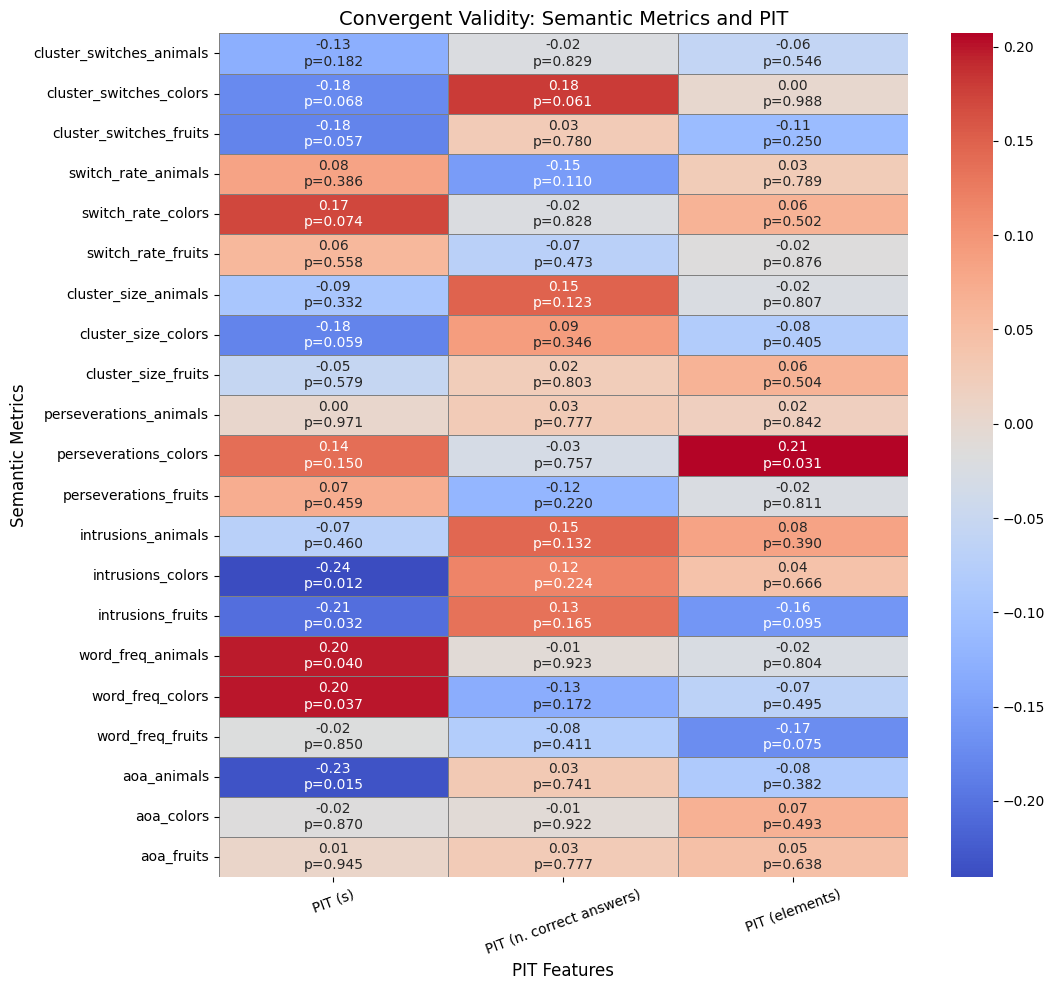

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

semantic_metric_columns = [col for col in df_wide.columns if any(
    col.startswith(prefix) for prefix in [
        'cluster_', 'switch_rate_', 'cluster_size_', 'perseverations_', 'intrusions_', 'word_freq_', 'aoa_'])]

spearman_results_cleaned = []

for sem in semantic_metric_columns:
    for pit in pit_features:
        valid_data = df_merged[[sem, pit]].dropna()
        if valid_data[sem].nunique() > 1 and valid_data[pit].nunique() > 1:
            corr, pval = spearmanr(valid_data[sem], valid_data[pit])
        else:
            corr, pval = np.nan, np.nan
        spearman_results_cleaned.append({
            'Semantic Feature': sem,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval
        })

numeric_matrix_cleaned = pd.DataFrame(index=semantic_metric_columns, columns=pit_features, dtype=float)
annotation_matrix_cleaned = pd.DataFrame(index=semantic_metric_columns, columns=pit_features, dtype=object)

for row in spearman_results_cleaned:
    sem = row['Semantic Feature']
    pit = row['PIT Feature']
    corr = row['Spearman Correlation']
    pval = row['p-value']
    numeric_matrix_cleaned.loc[sem, pit] = corr
    if not np.isnan(corr) and not np.isnan(pval):
        annotation_matrix_cleaned.loc[sem, pit] = f"{corr:.2f}\np={pval:.3f}"
    else:
        annotation_matrix_cleaned.loc[sem, pit] = "N/A"

plt.figure(figsize=(11, 10))
sns.heatmap(numeric_matrix_cleaned.astype(float), annot=annotation_matrix_cleaned, fmt='', cmap='coolwarm',
            cbar=True, linewidths=0.6, linecolor='gray', mask=numeric_matrix_cleaned.isna())
plt.title("Convergent Validity: Semantic Metrics and PIT", fontsize=14)
plt.xlabel("PIT Features", fontsize=12)
plt.ylabel("Semantic Metrics", fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Spearman + CI: 100%|██████████| 21/21 [00:27<00:00,  1.31s/it]


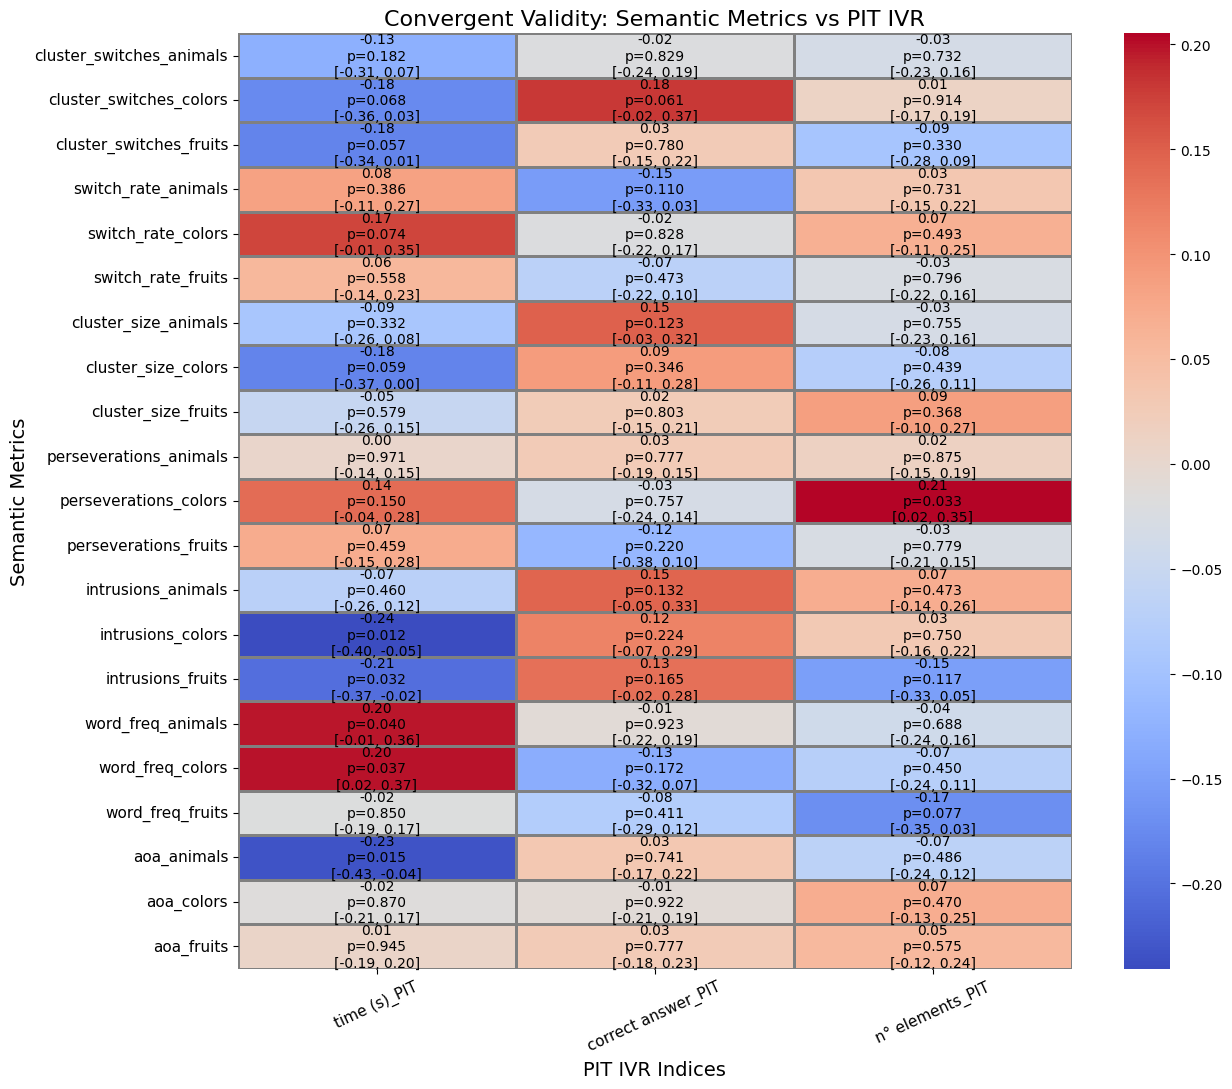

In [27]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 1. Caricamento dei dati
df_wide = pd.read_csv("df_wide.csv")
df_merged = pd.read_csv("df_merged (semantic+nps).csv")

# 2. Estrai metriche semantiche da df_wide
semantic_metric_columns = [col for col in df_wide.columns if any(
    col.startswith(prefix) for prefix in [
        'cluster_', 'switch_rate_', 'cluster_size_', 
        'perseverations_', 'intrusions_', 'word_freq_', 'aoa_'])]

# 3. Seleziona le feature PIT
pit_features = ["time (s)_PIT", "correct answer_PIT", "n° elements_PIT"]

# 4. Parametri bootstrap
n_bootstrap = 1000
ci_lower = 2.5
ci_upper = 97.5

# 5. Inizializza le matrici per i risultati
numeric_matrix = pd.DataFrame(index=semantic_metric_columns, columns=pit_features, dtype=float)
annotation_matrix = pd.DataFrame(index=semantic_metric_columns, columns=pit_features, dtype=object)
spearman_results_cleaned = []

# 6. Calcolo Spearman + CI bootstrap su df_merged
for sem in tqdm(semantic_metric_columns, desc="Spearman + CI"):
    for pit in pit_features:
        valid_data = df_merged[[sem, pit]].dropna()
        
        if valid_data[sem].nunique() > 1 and valid_data[pit].nunique() > 1:
            # Correlazione standard
            corr, pval = spearmanr(valid_data[sem], valid_data[pit])

            # Bootstrap per stimare l'intervallo di confidenza
            corr_values = []
            for _ in range(n_bootstrap):
                sample = valid_data.sample(n=len(valid_data), replace=True)
                if sample[sem].nunique() > 1 and sample[pit].nunique() > 1:
                    boot_corr, _ = spearmanr(sample[sem], sample[pit])
                    if not np.isnan(boot_corr):
                        corr_values.append(boot_corr)

            if len(corr_values) > 0:
                ci_low = np.percentile(corr_values, ci_lower)
                ci_high = np.percentile(corr_values, ci_upper)
            else:
                ci_low = ci_high = np.nan
        else:
            corr = pval = ci_low = ci_high = np.nan

        # Salvataggio nei risultati
        numeric_matrix.loc[sem, pit] = corr
        if not np.isnan(corr):
            annotation_matrix.loc[sem, pit] = f"{corr:.2f}\np={pval:.3f}\n[{ci_low:.2f}, {ci_high:.2f}]"
        else:
            annotation_matrix.loc[sem, pit] = "N/A"

        spearman_results_cleaned.append({
            'Semantic Feature': sem,
            'PIT Feature': pit,
            'Spearman Correlation': corr,
            'p-value': pval,
            '95% CI Lower': ci_low,
            '95% CI Upper': ci_high
        })

# 7. Visualizzazione heatmap
annotation_matrix = annotation_matrix.astype(str).fillna("N/A")
numeric_matrix = numeric_matrix.astype(float)

plt.figure(figsize=(13, 11)) 
sns.heatmap(
    numeric_matrix,
    annot=annotation_matrix.values,
    fmt='',
    cmap='coolwarm',
    cbar=True,
    linewidths=1.0,
    linecolor='gray',
    mask=numeric_matrix.isna(),
    annot_kws={"fontsize": 10, "color": "black", "va": "center"}
)
plt.title("Convergent Validity: Semantic Metrics vs PIT IVR", fontsize=16)
plt.xlabel("PIT IVR Indices", fontsize=14)
plt.ylabel("Semantic Metrics", fontsize=14)
plt.xticks(rotation=25, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=cf280e5d-731e-4415-8250-b9e26b4596bc' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>